<a href="https://colab.research.google.com/github/solitude-ui/heart-disease-supervised-learning/blob/main/Assesment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,mean_absolute_error, mean_squared_error, r2_score
import joblib


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df = pd.read_csv("/content/drive/MyDrive/ICTK - AI-ML/Datasets/heart_disease.csv")


In [8]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [9]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [10]:
df.shape


(1025, 14)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [12]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [13]:
# Checking missing value
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [14]:
#duplicate rows
df.duplicated().sum()

np.int64(723)

In [15]:
df = df.drop_duplicates()  # removing duplicates

# Encoding

In [16]:
columns_to_be_encoded = ["sex","fbs"]

le = LabelEncoder()

for col in columns_to_be_encoded:
    df[col] = le.fit_transform(df[col])

In [17]:


columns_to_onehot = ["cp","restecg","thal"]

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

encoded_data = encoder.fit_transform(df[columns_to_onehot])

In [18]:
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(columns_to_onehot),
    index=df.index
)

# Remove the original categorical columns:

df = df.drop(columns=columns_to_onehot)

#And combine them:

df = pd.concat([df, encoded_df], axis=1)

In [19]:
df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,2,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,53,1,140,203,1,155,1,3.1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,145,174,0,125,1,2.6,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,61,1,148,203,0,161,0,0.0,2,1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,62,0,138,294,1,106,0,1.9,1,3,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


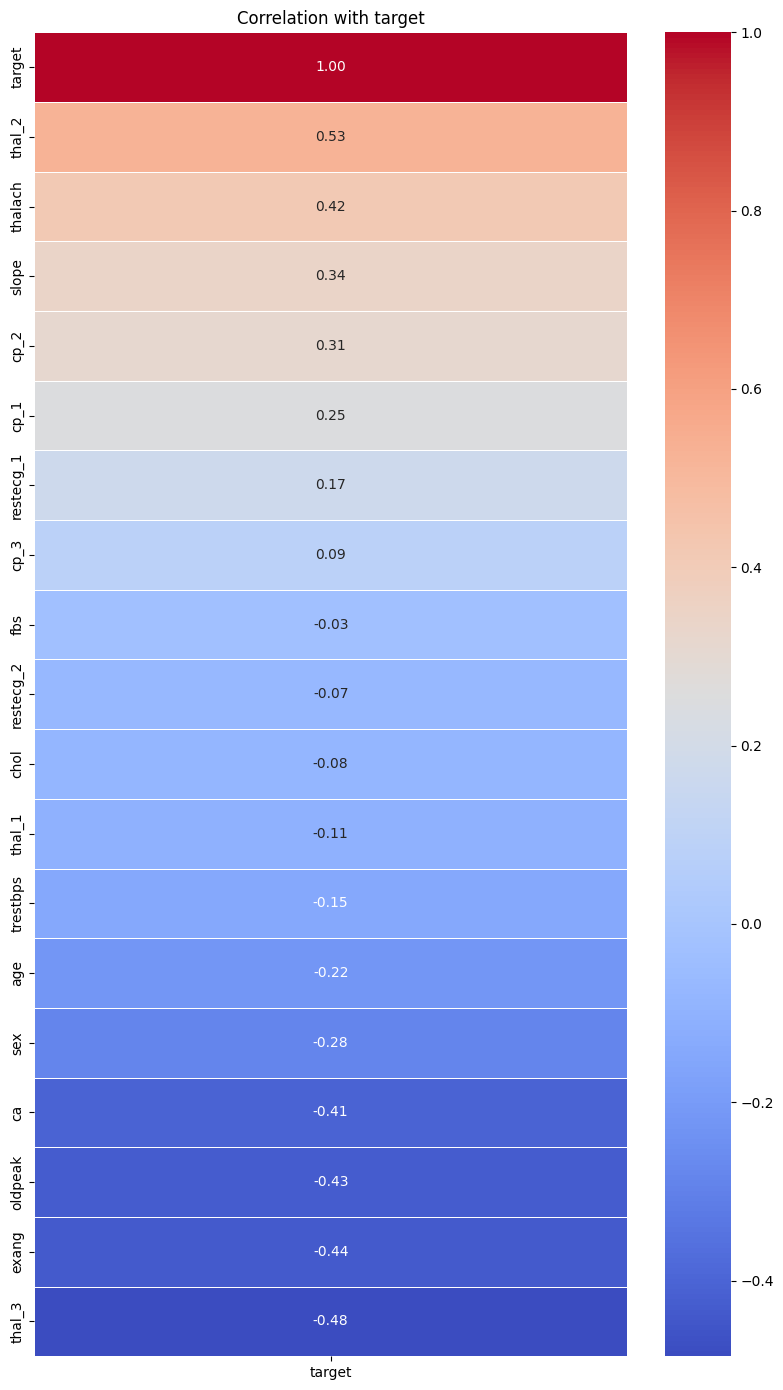

In [20]:
#finding correlation with target for classification
corr = df.select_dtypes(exclude="object").corr()

target_for_Classification_corr = corr[["target"]].sort_values(
    by="target",
    ascending=False
)

plt.figure(figsize=(8, 14))

sns.heatmap(
    target_for_Classification_corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation with target")
plt.tight_layout()
plt.show()

In [21]:
# Selecting features based on correlation with target

selected_features_cls = ['thalach','thal_2']


X_cls = df[selected_features_cls]
y_cls = df['target']

print("Selected Features:")
print(X_cls.columns)

Selected Features:
Index(['thalach', 'thal_2'], dtype='object')


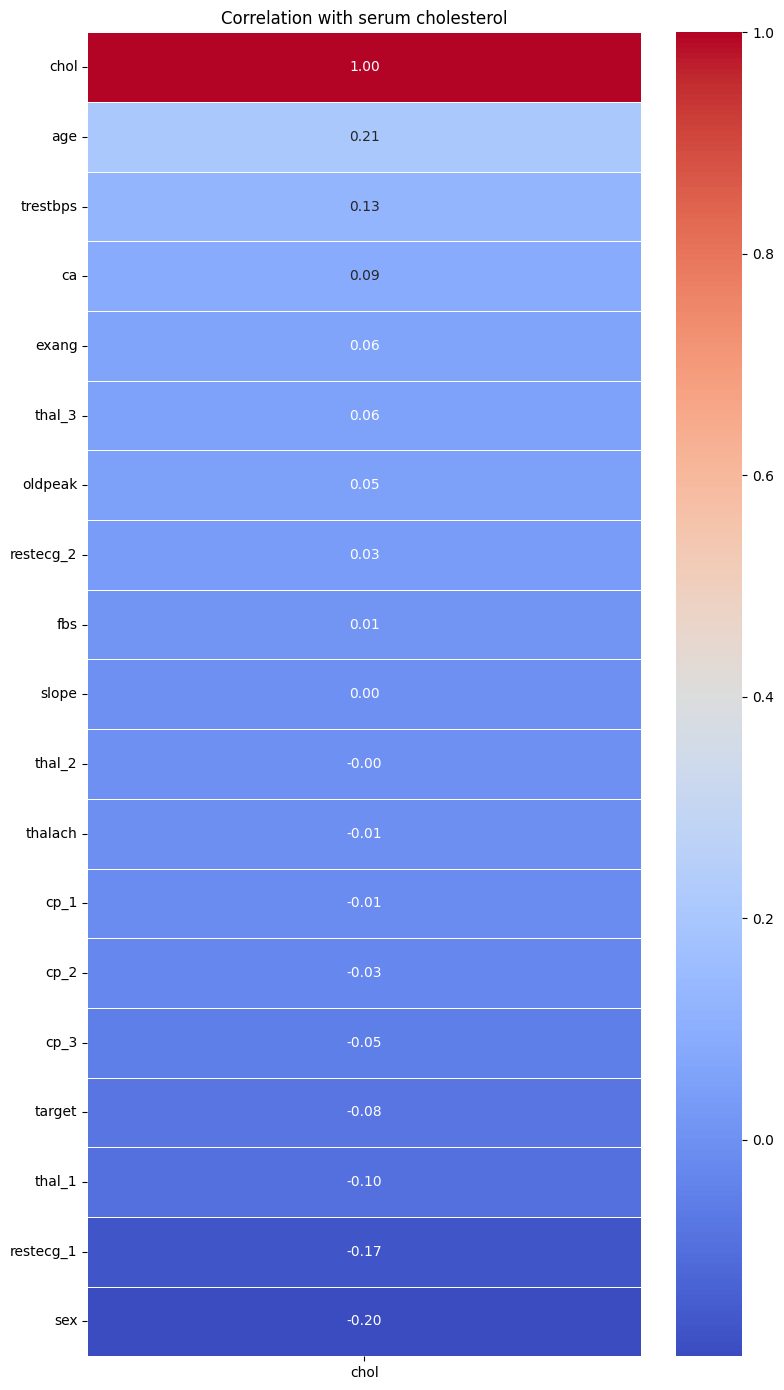

In [22]:
#finding correlation with serum cholesterol for regression
corr = df.select_dtypes(exclude="object").corr()

chol_for_regression_corr = corr[["chol"]].sort_values(
    by="chol",
    ascending=False
)

plt.figure(figsize=(8, 14))

sns.heatmap(
    chol_for_regression_corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation with serum cholesterol")
plt.tight_layout()
plt.show()

In [23]:

# Selecting features based on correlation with serum cholesterol

selected_features_reg = ['age']


X_reg = df[selected_features_reg]
y_reg = df['chol']

print("Selected Features:")
print(X_reg.columns)

Selected Features:
Index(['age'], dtype='object')


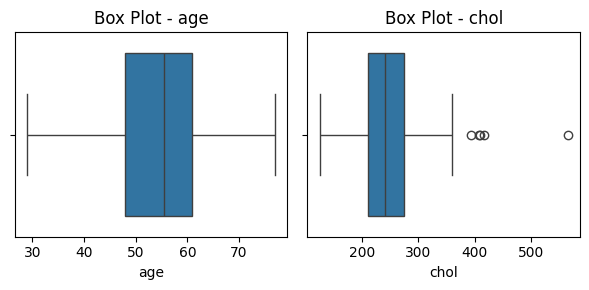

In [24]:
# Outlier handling using IQR

selected_features = ['age', 'chol']

plt.figure(figsize=(6,3))

for i, col in enumerate(selected_features):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot - {col}")

plt.tight_layout()
plt.show()




In [25]:
outlier_cols = ["age", "chol"]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

## train test split

In [26]:
# Train-test split for classification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

# Train-test split for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [27]:
# Feature scaling for classification

scaler_cls = StandardScaler()

X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

In [28]:
# Feature scaling for regression

scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

## model training for regression

In [29]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_reg_scaled, y_train_reg)


LinearRegression()

In [30]:
# SVM Regression
svr_model = SVR()
svr_model.fit(X_train_reg_scaled, y_train_reg)

SVR()

In [31]:
# Random Forest Regression
rf_reg_model = RandomForestRegressor(random_state=42)
rf_reg_model.fit(X_train_reg_scaled, y_train_reg)

RandomForestRegressor(random_state=42)

## model training for classification

In [32]:
# Logistic Regression
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_cls_scaled, y_train_cls)

LogisticRegression(random_state=42)

In [33]:
# KNN
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_cls_scaled, y_train_cls)

KNeighborsClassifier()

In [34]:

# Random Forest
rf_cls_model = RandomForestClassifier(random_state=42)
rf_cls_model.fit(X_train_cls_scaled, y_train_cls)


RandomForestClassifier(random_state=42)

## model evaluation

In [41]:

reg_models = {
    "Linear Regression": lr_model,
    "SVM Regression": svr_model,
    "Random Forest": rf_reg_model
}

for name, model in reg_models.items():

    y_pred = model.predict(X_test_reg_scaled)

    print(name + " Report\n")
    print("MAE:", mean_absolute_error(y_test_reg, y_pred))
    print("MSE:", mean_squared_error(y_test_reg, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred)))
    print("R2:", r2_score(y_test_reg, y_pred))
    print("-" * 40)

Linear Regression Report

MAE: 32.77024885468831
MSE: 1798.7168372161163
RMSE: 42.41128195676377
R2: 0.019433205636784634
----------------------------------------
SVM Regression Report

MAE: 32.00497406687755
MSE: 1774.0841196238
RMSE: 42.119877963068696
R2: 0.032861681106739815
----------------------------------------
Random Forest Report

MAE: 36.006066145496
MSE: 2068.7242966800304
RMSE: 45.48323093932565
R2: -0.12776080706310045
----------------------------------------


In [36]:
cls_models = {
    "Logistic Regression": log_model,
    "KNN": knn_model,
    "Random Forest": rf_cls_model
}

for name, model in cls_models.items():

    y_pred = model.predict(X_test_cls_scaled)

    print(name + " Report\n")
    print("Accuracy:", accuracy_score(y_test_cls, y_pred))
    print("Precision:", precision_score(y_test_cls, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test_cls, y_pred, zero_division=0))
    print("F1-Score:", f1_score(y_test_cls, y_pred, zero_division=0))
    print("-" * 40)

Logistic Regression Report

Accuracy: 0.7868852459016393
Precision: 0.7777777777777778
Recall: 0.8484848484848485
F1-Score: 0.8115942028985508
----------------------------------------
KNN Report

Accuracy: 0.7704918032786885
Precision: 0.7878787878787878
Recall: 0.7878787878787878
F1-Score: 0.7878787878787878
----------------------------------------
Random Forest Report

Accuracy: 0.6885245901639344
Precision: 0.71875
Recall: 0.696969696969697
F1-Score: 0.7076923076923077
----------------------------------------


In [37]:
#saving best regression model
best_model = svr_model

with open("best_regression_model.pkl", "wb") as file:
    joblib.dump(best_model, file)

with open("best_regression_model.pkl", "rb") as file:
    best_model = joblib.load(file)

y_pred = best_model.predict(X_test_reg_scaled)

In [38]:
#saving best classification model
best_model = log_model

with open("best_classification_model.pkl", "wb") as file:
    joblib.dump(best_model, file)

with open("best_classification_model.pkl", "rb") as file:
    best_model = joblib.load(file)

y_pred = best_model.predict(X_test_cls_scaled)